<a href="https://colab.research.google.com/github/welmi496/Introduction-to-Artificial-Intelligence/blob/main/Assignment8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Links:**
- Colab notebook link: https://colab.research.google.com/drive/1lvG8EmDMQbo7e1p_RIpPm4N3awc1ZZ6E?usp=sharing
- GitHub repository link: https://github.com/welmi496/Introduction-to-Artificial-Intelligence/blob/main/Assignment8.ipynb
- GitHub repository README link: https://github.com/welmi496/Introduction-to-Artificial-Intelligence/blob/main/README.md

In [1]:
# ============================================================
# Classification Assignment
# Dataset: Breast Cancer Wisconsin Dataset
# ============================================================

# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

# 2. Load Dataset
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print("First 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nTarget names:")
print(data.target_names)

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \


In [2]:
# 3. Quick Data Check
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nClass distribution:")
print(df["target"].value_counts())


Data types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst s

In [3]:
# 4. Data Cleaning
# Remove duplicates if any
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (569, 31)


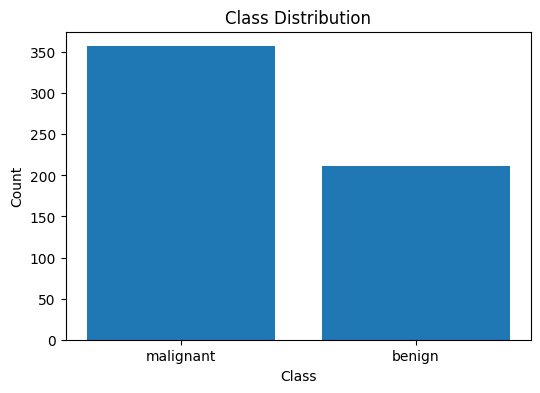

In [4]:
# 5. Exploratory Data Analysis (EDA)

# Class distribution
class_counts = df["target"].value_counts()
class_labels = ["malignant", "benign"]

plt.figure(figsize=(6,4))
plt.bar(class_labels, class_counts.values)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

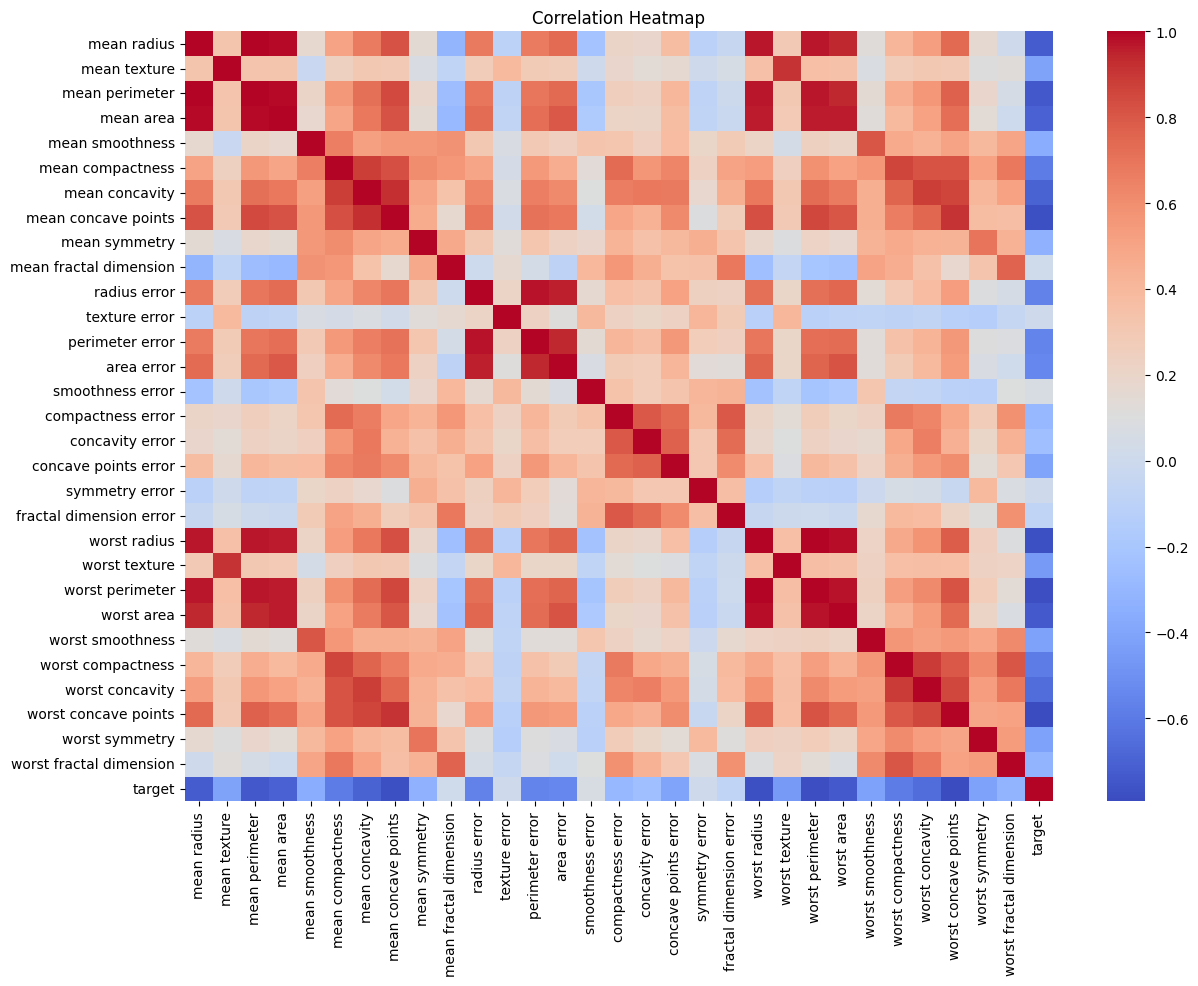

In [5]:
# 6. Correlation Heatmap
import seaborn as sns

plt.figure(figsize=(14,10))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

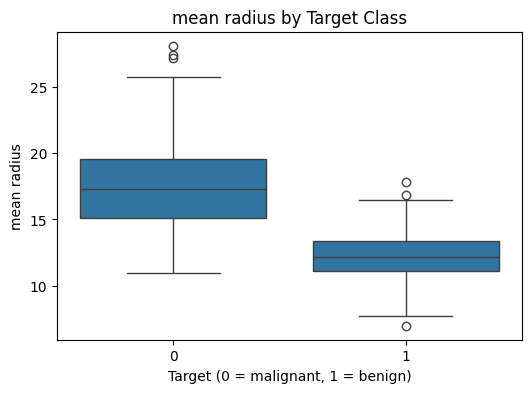

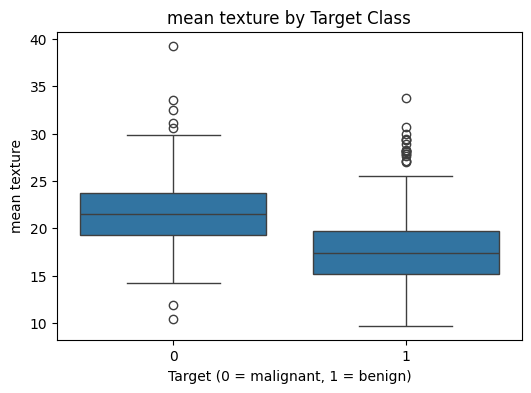

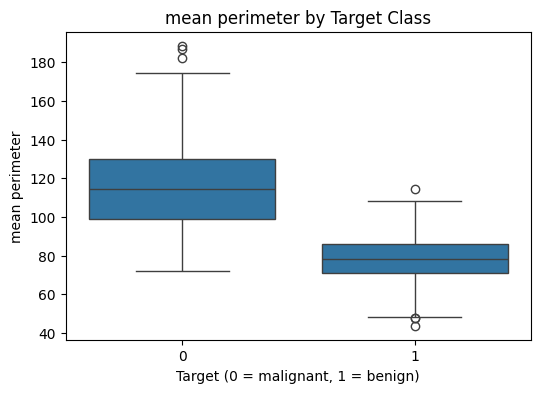

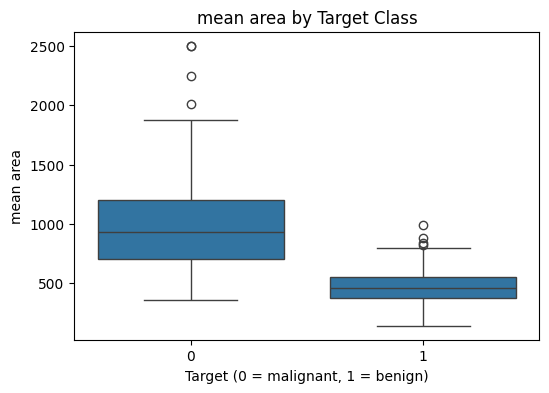

In [6]:
# 7. Visualize a few important features against the target
features_to_plot = ["mean radius", "mean texture", "mean perimeter", "mean area"]

for feature in features_to_plot:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="target", y=feature, data=df)
    plt.title(f"{feature} by Target Class")
    plt.xlabel("Target (0 = malignant, 1 = benign)")
    plt.ylabel(feature)
    plt.show()

In [7]:
# 8. Split features and target
X = df.drop("target", axis=1)
y = df["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (455, 30)
Testing set shape: (114, 30)


In [8]:
# 9. Feature Scaling for Logistic Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# 10. Model 1: Logistic Regression
log_model = LogisticRegression(max_iter=10000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Results
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1-score: 0.9861111111111112
ROC-AUC: 0.9953703703703703

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



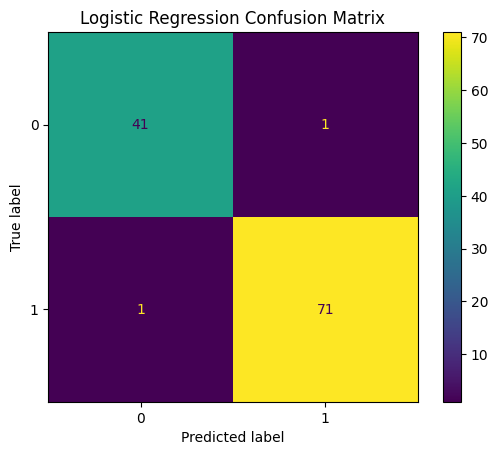

In [10]:
# 11. Logistic Regression Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

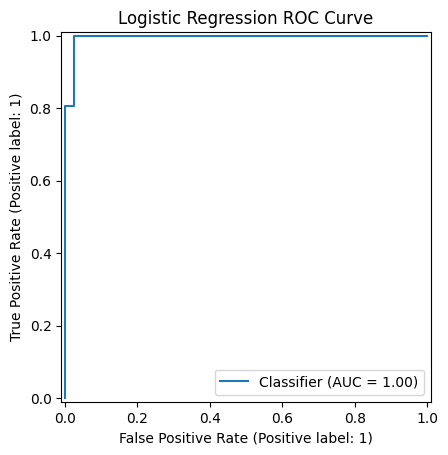

In [11]:
# 12. Logistic Regression ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob_log)
plt.title("Logistic Regression ROC Curve")
plt.show()

In [12]:
# 13. Model 2: Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1-score: 0.9655172413793104
ROC-AUC: 0.9937169312169312

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



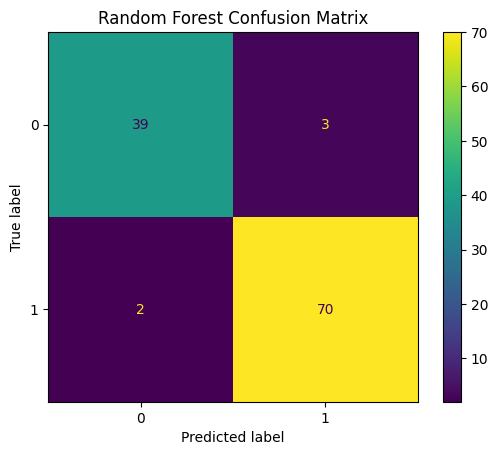

In [13]:
# 14. Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

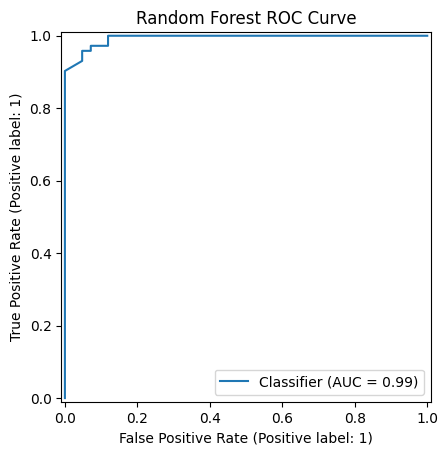

In [14]:
# 15. Random Forest ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob_rf)
plt.title("Random Forest ROC Curve")
plt.show()

In [15]:
# 16. Compare Model Performance
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
0  Logistic Regression  0.982456   0.986111  0.986111  0.986111  0.995370
1        Random Forest  0.956140   0.958904  0.972222  0.965517  0.993717


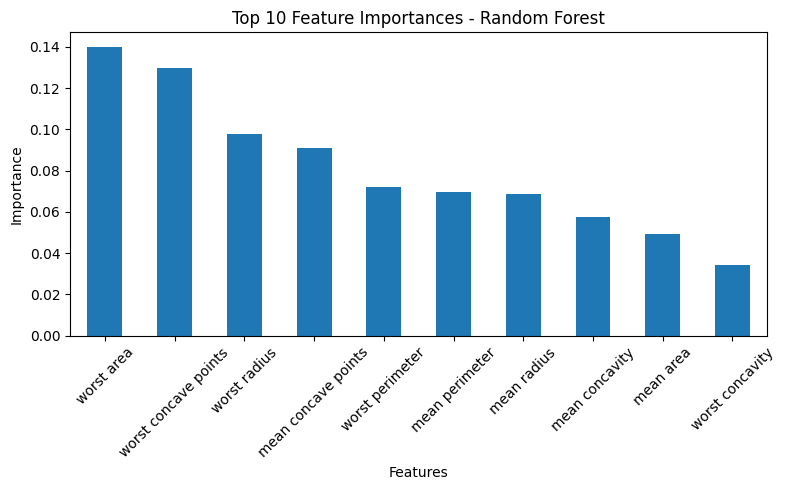

In [16]:
# 17. Feature Importance for Random Forest
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
feature_importances.plot(kind="bar")
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# 18. Inference / Conclusion
best_model = results.sort_values(by="F1-score", ascending=False).iloc[0]
print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model        Logistic Regression
Accuracy                0.982456
Precision               0.986111
Recall                  0.986111
F1-score                0.986111
ROC-AUC                  0.99537
Name: 0, dtype: object


In [18]:
# 19. Save results to CSV if needed
results.to_csv("model_comparison_results.csv", index=False)
print("Results saved to model_comparison_results.csv")

Results saved to model_comparison_results.csv
